In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

Mounted at /content/drive
GPU: True
Device: Tesla T4


In [ ]:
!pip install transformers datasets rouge-score -q

  Preparing metadata (setup.py) ... done


In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          get_linear_schedule_with_warmup)
import rouge_score
from rouge_score import rouge_scorer

DRIVE_PATH = '/content/drive/MyDrive/hate-speech-project'
DATA_PATH  = os.path.join(DRIVE_PATH, 'data')
MODEL_PATH = os.path.join(DRIVE_PATH, 'models', 'generation')
os.makedirs(MODEL_PATH, exist_ok=True)

MODEL_NAME  = 'microsoft/DialoGPT-medium'
MAX_LENGTH  = 256
BATCH_SIZE  = 8
EPOCHS      = 4
LR          = 5e-6

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [ ]:
train_df = pd.read_csv(os.path.join(DATA_PATH, 'conan_train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_PATH, 'conan_val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_PATH, 'conan_test.csv'))

# Drop any nulls
for df in [train_df, val_df, test_df]:
    df.dropna(inplace=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nSample:")
print(f"  Hate    : {train_df['hate_speech'].iloc[0]}")
print(f"  Counter : {train_df['counter_speech'].iloc[0]}")


Train: 11990 | Val: 1499 | Test: 1499

Sample:
  Hate    : I musulmani violentano le nostre donne e vanno castrati.
  Counter : Anche gli Italiani violentano, che si fa, ci castriamo tutti?


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer.add_special_tokens({'pad_token': '[PAD]'})

class CounterSpeechDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length
        # Pre-encode the EOS token id once
        self.eos_id = tokenizer.eos_token_id
        self.pad_id = tokenizer.pad_token_id

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        hate    = str(row['hate_speech'])
        counter = str(row['counter_speech'])

        hate_ids    = self.tokenizer.encode(hate,    add_special_tokens=False)
        counter_ids = self.tokenizer.encode(counter, add_special_tokens=False)

        # Format: [hate tokens] [EOS] [counter tokens] [EOS]
        input_ids = hate_ids + [self.eos_id] + counter_ids + [self.eos_id]

        # Truncate from the right if too long
        if len(input_ids) > self.max_length:
            input_ids = input_ids[:self.max_length]

        # Pad to max_length
        pad_len = self.max_length - len(input_ids)
        attention_mask = [1] * len(input_ids) + [0] * pad_len
        input_ids      = input_ids + [self.pad_id] * pad_len

        input_ids      = torch.tensor(input_ids,      dtype=torch.long)
        attention_mask = torch.tensor(attention_mask, dtype=torch.long)

        # The model learns to GENERATE counter-speech
        labels = input_ids.clone()
        sep_position = len(hate_ids) + 1   # position just after first EOS
        labels[:sep_position] = -100        # mask hate speech + separator
        labels[input_ids == self.pad_id] = -100  # mask padding (now safe, PAD ≠ EOS)

        return {
            'input_ids':      input_ids,
            'attention_mask': attention_mask,
            'labels':         labels
        }

train_dataset = CounterSpeechDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = CounterSpeechDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = CounterSpeechDataset(test_df,  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Vocab size    : {len(tokenizer)} (after adding [PAD])")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Train batches : 1499
Vocab size    : 50258 (after adding [PAD])


In [ ]:
print("Loading DialoGPT-medium...")

# Load fresh from HuggingFace
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,                        # 'microsoft/DialoGPT-medium'
    torch_dtype=torch.float32          # CRITICAL: force float32 for stable training
)

model.resize_token_embeddings(len(tokenizer))
model.tie_weights()

# Verify dtype is float32 throughout
sample_dtype = next(model.parameters()).dtype
print(f"✅ Model dtype: {sample_dtype}")
assert sample_dtype == torch.float32, f"Wrong dtype: {sample_dtype}"

# Initialize new [PAD] embedding to mean of existing ones
with torch.no_grad():
    embed_weight = model.transformer.wte.weight
    embed_weight[-1] = embed_weight[:-1].mean(dim=0)

model.config.vocab_size = len(tokenizer)
model.config.pad_token_id = tokenizer.pad_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id

model = model.to(device)

print(f"✅ Vocab size   : {model.config.vocab_size}")
print(f"✅ PAD token id : {tokenizer.pad_token_id}")
print(f"✅ EOS token id : {tokenizer.eos_token_id}")

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=0.01, eps=1e-8
)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
print(f"✅ Parameters   : {sum(p.numel() for p in model.parameters()):,}")
print(f"✅ Total steps  : {total_steps}")

Loading DialoGPT-medium...


`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/863M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/863M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: microsoft/DialoGPT-medium
Key                              | Status     |  | 
---------------------------------+------------+--+-
transformer.h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


✅ Model dtype: torch.float32
✅ Vocab size   : 50258
✅ PAD token id : 50257
✅ EOS token id : 50256
✅ Parameters   : 354,824,192
✅ Total steps  : 5996


In [ ]:
import math

def train_epoch(model, loader, optimizer, scheduler, device, epoch_num=1):
    model.train()
    total_loss, effective_batches = 0, 0

    optimizer.zero_grad()

    for i, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        # Sanity check on first batch of first epoch only
        if i == 0 and epoch_num == 1:
            supervised = (labels != -100).sum().item()
            print(f"  [Sanity] Batch 0: supervised tokens = {supervised}")
            if supervised == 0:
                raise RuntimeError("Zero supervised tokens in first batch — check dataset masking!")

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss

        if loss is None or not torch.isfinite(loss):
            if effective_batches == 0 and i < 5:
                # Deep diagnostic on early failures
                logits = outputs.logits
                print(f"  [DIAG] Batch {i}: logits has NaN={torch.isnan(logits).any().item()}, "
                      f"Inf={torch.isinf(logits).any().item()}")
                print(f"  [DIAG] input_ids range: [{input_ids.min()}, {input_ids.max()}]")
                print(f"  [DIAG] labels range (non-masked): "
                      f"{labels[labels != -100].unique()[:10]}")
            print(f"  [WARNING] Non-finite loss at batch {i}, skipping.")
            optimizer.zero_grad()   # clear any partial gradients
            continue

        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Catch NaN gradients — these happen when embeddings produce ±inf
        if not math.isfinite(grad_norm):
            print(f"  [WARNING] NaN gradient norm at batch {i}, skipping update.")
            optimizer.zero_grad()
            continue

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        effective_batches += 1

        if effective_batches % 100 == 0:
            print(f"  Batch {i}/{len(loader)}"
                  f" — Loss: {loss.item():.4f}"
                  f" | GradNorm: {grad_norm:.3f}"
                  f" | LR: {scheduler.get_last_lr()[0]:.2e}")

    if effective_batches == 0:
        raise RuntimeError("ALL batches skipped. Run the deep diagnostic cell below.")
    return total_loss / effective_batches


def evaluate_generation(model, loader, device):
    model.eval()
    total_loss, effective_batches = 0, 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            loss = outputs.loss

            if loss is None or not torch.isfinite(loss):
                continue

            total_loss += loss.item()
            effective_batches += 1

    if effective_batches == 0:
        raise RuntimeError("All validation batches skipped.")
    return total_loss / effective_batches

print("✅ Training functions defined.")

✅ Training functions defined.


In [ ]:
import math

print("=== STEP 1: Check a single sample ===")
sample = train_dataset[0]
iids = sample['input_ids']
lbls = sample['labels']
amsk = sample['attention_mask']

print(f"input_ids shape    : {iids.shape}")
print(f"attention_mask sum : {amsk.sum().item()}  (non-pad tokens)")
print(f"labels == -100     : {(lbls == -100).sum().item()} positions masked")
print(f"labels != -100     : {(lbls != -100).sum().item()} positions supervised")
print(f"Any NaN in input_ids? {torch.isnan(iids.float()).any()}")

if (lbls != -100).sum() == 0:
    print("❌ PROBLEM: All labels are masked! Nothing to learn from.")
else:
    print("✅ Labels look OK — supervised positions exist")

print("\n=== STEP 2: Forward pass on one batch ===")
model.train()
batch = next(iter(train_loader))
input_ids      = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)
labels         = batch['labels'].to(device)

print(f"Batch input_ids range : [{input_ids.min()}, {input_ids.max()}]")
print(f"Vocab size             : {len(tokenizer)}")
print(f"Model embed size       : {model.config.vocab_size}")

if input_ids.max() >= model.config.vocab_size:
    print("❌ TOKEN ID OUT OF RANGE — this is your NaN source!")
    print(f"   Max token id {input_ids.max().item()} >= vocab {model.config.vocab_size}")
else:
    print("✅ All token IDs within vocab range")

print(f"\nLabel stats:")
print(f"  Supervised  : {(labels != -100).sum().item()}")
print(f"  Masked(-100): {(labels == -100).sum().item()}")

with torch.no_grad():
    out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = out.loss
    print(f"\nTest forward pass loss: {loss.item()}")
    if not torch.isfinite(loss):
        print("❌ Loss is NaN/Inf on first forward pass")
    else:
        print("✅ Forward pass clean")

=== STEP 1: Check a single sample ===
input_ids shape    : torch.Size([256])
attention_mask sum : 43  (non-pad tokens)
labels == -100     : 234 positions masked
labels != -100     : 22 positions supervised
Any NaN in input_ids? False
✅ Labels look OK — supervised positions exist

=== STEP 2: Forward pass on one batch ===
Batch input_ids range : [0, 50257]
Vocab size             : 50258
Model embed size       : 50258
✅ All token IDs within vocab range

Label stats:
  Supervised  : 237
  Masked(-100): 1811


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



Test forward pass loss: 4.645782947540283
✅ Forward pass clean


In [ ]:
model.train()
optimizer.zero_grad()
batch = next(iter(train_loader))
out = model(
    input_ids=batch['input_ids'].to(device),
    attention_mask=batch['attention_mask'].to(device),
    labels=batch['labels'].to(device)
)
out.loss.backward()

# Find exactly which parameter has NaN gradient
for name, p in model.named_parameters():
    if p.grad is not None and not torch.isfinite(p.grad).all():
        print(f"NaN grad in: {name} | shape: {p.grad.shape}")
        print(f"  param range : [{p.data.min():.4f}, {p.data.max():.4f}]")
        print(f"  grad sample : {p.grad.flatten()[:8]}")
optimizer.zero_grad()

In [ ]:
print("Starting DialoGPT fine-tuning...\n")

best_val_loss = float('inf')
best_path     = os.path.join(MODEL_PATH, 'dialogpt_best.pt')
history       = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    print(f"{'='*50}\nEPOCH {epoch}/{EPOCHS}\n{'='*50}")

    train_loss = train_epoch(model, train_loader, optimizer,
                             scheduler, device, epoch_num=epoch)  # <-- pass epoch
    val_loss   = evaluate_generation(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss,   20))
    print(f"\nTrain Loss: {train_loss:.4f} (PPL {train_ppl:.1f})"
          f" | Val Loss: {val_loss:.4f} (PPL {val_ppl:.1f})")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(MODEL_PATH)
        tokenizer.save_pretrained(MODEL_PATH)
        print(f"*** Best model saved (Val Loss: {val_loss:.4f}) ***")

print(f"\nTraining complete. Best Val Loss: {best_val_loss:.4f}")

Starting DialoGPT fine-tuning...

EPOCH 1/4
  [Sanity] Batch 0: supervised tokens = 288
  Batch 99/1499 — Loss: 5.2065 | GradNorm: 5.138 | LR: 8.35e-07
  Batch 199/1499 — Loss: 5.1200 | GradNorm: 3.933 | LR: 1.67e-06
  Batch 299/1499 — Loss: 5.2390 | GradNorm: 3.719 | LR: 2.50e-06
  Batch 399/1499 — Loss: 4.3615 | GradNorm: 3.749 | LR: 3.34e-06
  Batch 499/1499 — Loss: 4.3594 | GradNorm: 3.338 | LR: 4.17e-06
  Batch 599/1499 — Loss: 4.3622 | GradNorm: 4.058 | LR: 5.00e-06
  Batch 699/1499 — Loss: 3.9855 | GradNorm: 3.131 | LR: 4.91e-06
  Batch 799/1499 — Loss: 3.8549 | GradNorm: 2.658 | LR: 4.81e-06
  Batch 899/1499 — Loss: 3.9565 | GradNorm: 4.900 | LR: 4.72e-06
  Batch 999/1499 — Loss: 4.0605 | GradNorm: 3.276 | LR: 4.63e-06
  Batch 1099/1499 — Loss: 3.6391 | GradNorm: 3.282 | LR: 4.54e-06
  Batch 1199/1499 — Loss: 3.7445 | GradNorm: 3.813 | LR: 4.44e-06
  Batch 1299/1499 — Loss: 3.6566 | GradNorm: 3.468 | LR: 4.35e-06
  Batch 1399/1499 — Loss: 3.8625 | GradNorm: 3.899 | LR: 4.26e-06

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

*** Best model saved (Val Loss: 3.3993) ***
EPOCH 2/4
  Batch 99/1499 — Loss: 3.2084 | GradNorm: 3.408 | LR: 4.07e-06
  Batch 199/1499 — Loss: 3.1056 | GradNorm: 3.729 | LR: 3.98e-06
  Batch 299/1499 — Loss: 3.7187 | GradNorm: 3.465 | LR: 3.89e-06
  Batch 399/1499 — Loss: 3.3045 | GradNorm: 3.372 | LR: 3.80e-06
  Batch 499/1499 — Loss: 3.6544 | GradNorm: 3.926 | LR: 3.70e-06
  Batch 599/1499 — Loss: 3.1556 | GradNorm: 3.754 | LR: 3.61e-06
  Batch 699/1499 — Loss: 3.3949 | GradNorm: 2.832 | LR: 3.52e-06
  Batch 799/1499 — Loss: 3.3611 | GradNorm: 3.824 | LR: 3.43e-06
  Batch 899/1499 — Loss: 3.5362 | GradNorm: 3.322 | LR: 3.33e-06
  Batch 999/1499 — Loss: 3.2000 | GradNorm: 2.995 | LR: 3.24e-06
  Batch 1099/1499 — Loss: 3.2137 | GradNorm: 4.003 | LR: 3.15e-06
  Batch 1199/1499 — Loss: 3.8536 | GradNorm: 3.488 | LR: 3.05e-06
  Batch 1299/1499 — Loss: 3.2337 | GradNorm: 3.044 | LR: 2.96e-06
  Batch 1399/1499 — Loss: 3.3776 | GradNorm: 3.093 | LR: 2.87e-06

Train Loss: 3.4091 (PPL 30.2) | 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

*** Best model saved (Val Loss: 3.1857) ***
EPOCH 3/4
  Batch 99/1499 — Loss: 3.3147 | GradNorm: 4.258 | LR: 2.68e-06
  Batch 199/1499 — Loss: 3.5210 | GradNorm: 3.916 | LR: 2.59e-06
  Batch 299/1499 — Loss: 3.4538 | GradNorm: 4.048 | LR: 2.50e-06
  Batch 399/1499 — Loss: 3.0701 | GradNorm: 3.484 | LR: 2.41e-06
  Batch 499/1499 — Loss: 2.8585 | GradNorm: 3.943 | LR: 2.31e-06
  Batch 599/1499 — Loss: 3.1109 | GradNorm: 4.091 | LR: 2.22e-06
  Batch 699/1499 — Loss: 2.8206 | GradNorm: 2.932 | LR: 2.13e-06
  Batch 799/1499 — Loss: 3.1912 | GradNorm: 2.852 | LR: 2.04e-06
  Batch 899/1499 — Loss: 2.9530 | GradNorm: 3.176 | LR: 1.94e-06
  Batch 999/1499 — Loss: 3.4200 | GradNorm: 3.007 | LR: 1.85e-06
  Batch 1099/1499 — Loss: 3.2304 | GradNorm: 3.025 | LR: 1.76e-06
  Batch 1199/1499 — Loss: 3.1602 | GradNorm: 3.423 | LR: 1.67e-06
  Batch 1299/1499 — Loss: 3.4228 | GradNorm: 2.913 | LR: 1.57e-06
  Batch 1399/1499 — Loss: 3.1196 | GradNorm: 3.924 | LR: 1.48e-06

Train Loss: 3.2449 (PPL 25.7) | 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

*** Best model saved (Val Loss: 3.1030) ***
EPOCH 4/4
  Batch 99/1499 — Loss: 3.1963 | GradNorm: 3.100 | LR: 1.30e-06
  Batch 199/1499 — Loss: 3.0970 | GradNorm: 3.387 | LR: 1.20e-06
  Batch 299/1499 — Loss: 3.3807 | GradNorm: 3.099 | LR: 1.11e-06
  Batch 399/1499 — Loss: 3.4016 | GradNorm: 3.126 | LR: 1.02e-06
  Batch 499/1499 — Loss: 3.2388 | GradNorm: 3.905 | LR: 9.26e-07
  Batch 599/1499 — Loss: 2.8590 | GradNorm: 3.726 | LR: 8.33e-07
  Batch 699/1499 — Loss: 3.0699 | GradNorm: 2.933 | LR: 7.40e-07
  Batch 799/1499 — Loss: 2.8403 | GradNorm: 3.751 | LR: 6.48e-07
  Batch 899/1499 — Loss: 3.2374 | GradNorm: 3.429 | LR: 5.55e-07
  Batch 999/1499 — Loss: 3.2450 | GradNorm: 4.031 | LR: 4.62e-07
  Batch 1099/1499 — Loss: 3.0955 | GradNorm: 3.504 | LR: 3.70e-07
  Batch 1199/1499 — Loss: 3.0254 | GradNorm: 3.492 | LR: 2.77e-07
  Batch 1299/1499 — Loss: 3.1260 | GradNorm: 3.065 | LR: 1.84e-07
  Batch 1399/1499 — Loss: 3.2592 | GradNorm: 2.992 | LR: 9.17e-08

Train Loss: 3.1701 (PPL 23.8) | 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

*** Best model saved (Val Loss: 3.0779) ***

Training complete. Best Val Loss: 3.0779


In [ ]:
# Load best model the correct way (save_pretrained format, not state_dict)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, torch_dtype=torch.float32).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

def generate_counterspeech(hate_speech: str, model, tokenizer,
                            max_new_tokens: int = 100) -> str:
    model.eval()
    input_text = f"{hate_speech}{tokenizer.eos_token}"
    inputs = tokenizer(
        input_text,
        return_tensors='pt',
        truncation=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_k=50,
            top_p=0.92,
            temperature=0.8,
            repetition_penalty=1.3,   # 3.5 is way too high — causes word fragments
            pad_token_id=tokenizer.pad_token_id,   # use [PAD], not EOS
            eos_token_id=tokenizer.eos_token_id
        )

    generated = output_ids[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

print("=" * 55)
print("GENERATION EXAMPLES")
print("=" * 55)

test_examples = test_df.sample(5, random_state=42)
for _, row in test_examples.iterrows():
    print(f"\nHate Speech : {row['hate_speech'][:120]}")
    print(f"Reference   : {row['counter_speech'][:120]}")
    generated = generate_counterspeech(row['hate_speech'], model, tokenizer)
    print(f"Generated   : {generated}")
    print("-" * 55)

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GENERATION EXAMPLES

Hate Speech : Veiled women are subjected and forced to wear the headscarf.
Reference   : You are intolerant and ignorant.
Generated   : You are right. In this case, it is not veiled women who are subjected to be veil'd, but those who voluntarily become veil themselves: they do not have any obligation to follow their religion.
-------------------------------------------------------

Hate Speech : It is obvious that this girl is at risk of FGM. Her parents are Muslims!
Reference   : Fgm is not a Muslim-only issue. It is routed in the cultures of certain countries, not in religion.
Generated   : It is also clear that these people are not following the teachings of Islam and doing it to their children instead.
-------------------------------------------------------

Hate Speech : L'islam et le terrorisme sont des synonymes.
Reference   : C'est faux de généraliser car il y aurait donc 1,5 milliards de terroristes.
Generated   : L'islam est une religion qui ne mérite pas

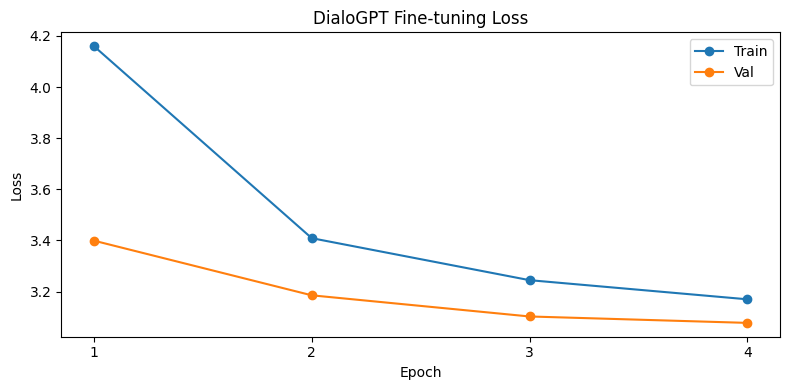


Saved to Drive:
  /content/drive/MyDrive/hate-speech-project/models/generation/  (model weights + config)
  /content/drive/MyDrive/hate-speech-project/models/generation/dialogpt_tokenizer/
  /content/drive/MyDrive/hate-speech-project/models/generation/generation_history.csv
  /content/drive/MyDrive/hate-speech-project/models/generation/generation_curves.png


In [ ]:
import matplotlib.pyplot as plt

tokenizer.save_pretrained(os.path.join(MODEL_PATH, 'dialogpt_tokenizer'))

# Save training history
pd.DataFrame(history).to_csv(
    os.path.join(MODEL_PATH, 'generation_history.csv'), index=False
)

# Plot — use epoch numbers on x-axis
fig, ax = plt.subplots(figsize=(8, 4))
epochs = range(1, len(history['train_loss']) + 1)
ax.plot(epochs, history['train_loss'], label='Train', marker='o')
ax.plot(epochs, history['val_loss'],   label='Val',   marker='o')
ax.set_title('DialoGPT Fine-tuning Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_xticks(list(epochs))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'generation_curves.png'), dpi=150)
plt.show()

print("\nSaved to Drive:")
print(f"  {MODEL_PATH}/  (model weights + config)")
print(f"  {MODEL_PATH}/dialogpt_tokenizer/")
print(f"  {MODEL_PATH}/generation_history.csv")
print(f"  {MODEL_PATH}/generation_curves.png")